En esta primera instancia se buscará conectarse a las entidades correspondientes para la correcta extracción de datos financieros relativos a como el peso mexicano reacciona a eventos del mundo real

In [ ]:
pip install yfinance pandas

In [38]:
import numpy as np

In [1]:
import yfinance as yf
import pandas as pd

# Definimos los tickers del mercado global
# ^VIX es el Índice del Miedo  y ^TNX es el rendimiento de la tasa del Tesoro de EE.UU. a 10 años
tickers = {
    "VIX": "^VIX",
    "Tasa_Fed_10Y": "^TNX"
}

# Descargamos los datos históricos diarios usando la columna 'Close'
df_raw = yf.download(list(tickers.values()), start="2021-01-01", end="2026-07-17")["Close"]

# Creamos una copia limpia y renombramos las columnas con nuestros nombres legibles
data_global = df_raw.copy()
data_global = data_global.rename(columns={ "^VIX": "VIX", "^TNX": "Tasa_Fed_10Y" })

# Visualizamos el esqueleto inicial de nuestro data de análisis
data_global.head(10)


[*********************100%***********************]  2 of 2 completed


Ticker,Tasa_Fed_10Y,VIX
Date,,
2021-01-04,0.917,26.969999
2021-01-05,0.955,25.340000
2021-01-06,1.042,25.070000
2021-01-07,1.071,22.370001
2021-01-08,1.105,21.559999
2021-01-11,1.132,24.080000
2021-01-12,1.138,23.330000
2021-01-13,1.088,22.209999
2021-01-14,1.129,23.250000


EUA emite vales de deuda, cuando uno compra un bono a ej 10 años le esta prestando dinero a EEUU y elllos prometen pagar una tasa de interés anual fija durante una década, ej: 0.917, esa es la Tasa_Fed_10Y.

En ese momento, el gobierno pagaba apenas 0.917% anual de interés por prestarles dinero.

En física: Una partícula se mueve hacia donde el potencial es más bajo o hacia donde la ufuerza gavitacional es mayor. En finanzas el capital global actua de la misma manera

* Bono de estados unidos: Se considera el activo libre de riesgo del mundo ie; el riesgo de que EEUU quiebre y no te pague es prácticamente cero.

¿Qué fenómeno ocurre?
Cuando la tasa de EEUU es muy baja los fondos de inversión caen en cuenta que no les conviene dejar su dinero en Nueva York pq ganarían muy poco, por eso se lo traen a México que es un mercado emergente y ofrece tasas más altas para compensar su riesgo. Así, el dinero fluye hacia México, compran pesos y el peso se fortalece.

* Fuerza de gravedad del dólar:
Cuando la tasa de EEUU sube ie aumenta el rendimiento para los que compren esos bonos. La fuerza de gravedad del dolar se vuelve más intensa y los inversionistas caen en cuenta que conviene por cuestiones de que en EEUU hay menos riesgo mejor retiran sus fondos de México vendiendo sus pesos y comprando dólar. Estas acciones provocan que el peso Mexicano sifra devaluaciones salvajes


Por eso Tasa_Fed_10Y es relevante ya que es la variable macroeconómica de control que mide la atracción que ejerce el dolar sobre los flujos de capital que entran y salen de México.

* ¿qué significa que el peso caiga?: Nos referimos a que se devalúa o debilita. 
Cuando el peso caiga, veremos que el USD_MXN sube. Porque si el peso se debilita, se necesitan más pesos para comprar la misma mercancía que en este caso es el dolar.En este caso el dolar se encarece ante México.

* ¿Dónde se intercambian las monedas? 
En un mercado global llamada FX: Foreign Exchange o Forex.

* ¿Cómo es el proceso en el que un fondo extrangero que tiene dinero en México decide llevarselo ?
1- Venden sus posiciones locales: Si el fondo tenía acciones en la bolsa mexicana o bonos de gobierno Mexicano (CETES), los vende en el mercado interno y le pagan con Pesos Mexicanos.

2- Van a FX a cambiar el dinero: Avienta los X millones de pesos dentro del mercado y pide dólares a cambio.
3- Lo anterior lo venden a los Market Makers que son algoritmos y bancos obligados a comprar y vender continuamente.

4- Como hay esceso masivo de personas aventando (vendiendo) pesos y una escasez de personas dispuestas a soltar sus dólares, el precio del dolar sube por pura ley de oferta y demanda así el peso se devalúa.


Justo aquí, cuando los inversionistas huye de México y compran esos dólares en el mercado cambiario, los mueven de inmediato a las cuentas en Nueva York y compran los bonos del Tesoro de EEUU (la Tasa_Fed_10Y)

* ¿Cómo funciona la secuencia de un choque financiero global?
Funciona semejante a un efecto Dominó o una onda de choque en cadena.

1- Explota una crisis (Aumenta el VIX): ej Hay una tensión o un banco de europa quiebra, el pánico a nivel global se dispara. El VIX pasa de equilibrio relativamente estable a un estado con mucha entropía. ie; en este caso el termómetro marca mucha fiebre.

2- Los algorítmos y directivos entran en pánico, su prioridad ahora no es ganar dinero sino, No perder el capital.

3- Como el Peso Mexicano es la moneda más líquida y fácil de vender de todos los países en desarrollo, los fondos la usan como su válvula de escáe rápido. No importa si la economía de México esta bien o mal, por puro pánico global los inversionistas venden sus activos en pesos, saturan el mercado FX exigiendo dólares a cambio y posteriormente se refugian en los bonos de EEUU

Ahora, para traer la variable que vamos a predecir que es el tipo de cambio USD/MXN, para extraer el Dólar FIX

In [2]:
import yfinance as yf

# Definimos el ticker del Peso Mexicano en Yahoo Finance
# MXN=X representa el par cambiario USD/MXN
ticker_peso = {"USD_MXN": "MXN=X"}

# Descargamos la serie histórica del tipo de cambio
df_peso_raw = yf.download(list(ticker_peso.values()), start="2021-01-01", end="2026-07-17")["Close"]

# Creamos una copia limpia y renombramos la columna
df_peso = pd.DataFrame(df_peso_raw.copy())
df_peso.columns = ticker_peso.keys()

# Visualizamos las primeras filas para validar la estructura del dólar
df_peso.head(10)


[*********************100%***********************]  1 of 1 completed


,USD_MXN
Date,
2021-01-01,19.874500
2021-01-04,19.847500
2021-01-05,19.942450
2021-01-06,19.902201
2021-01-07,19.655769
2021-01-08,20.000099
2021-01-11,20.050489
2021-01-12,20.062401
2021-01-13,19.794430


In [3]:
# Unimos las dos tablas usando el índice 'Date' como eje de coordenadas temporal
# 'inner' asegura que solo se queden las fechas que coinciden exactamente en ambas bases de datos
df_main = pd.merge(df_peso, data_global, left_index=True, right_index=True, how="inner")

# Validamos que no existan valores nulos (NaN) provocados por la fusión
print("--- Conteo de Valores Nulos por Variable ---")
print(df_main.isna().sum())

# Visualizamos la estructura final de nuestra matriz de análisis de riesgo
print("\n--- Estructura de la Matriz Maestra (Primeras Filas) ---")
df_main.head(10)


--- Conteo de Valores Nulos por Variable ---
USD_MXN         0
Tasa_Fed_10Y    1
VIX             0
dtype: int64

--- Estructura de la Matriz Maestra (Primeras Filas) ---


,USD_MXN,Tasa_Fed_10Y,VIX
Date,,,
2021-01-04,19.847500,0.917,26.969999
2021-01-05,19.942450,0.955,25.340000
2021-01-06,19.902201,1.042,25.070000
2021-01-07,19.655769,1.071,22.370001
2021-01-08,20.000099,1.105,21.559999
2021-01-11,20.050489,1.132,24.080000
2021-01-12,20.062401,1.138,23.330000
2021-01-13,19.794430,1.088,22.209999
2021-01-14,19.836349,1.129,23.250000


* USD_MXN representa el precio de 1 dólar medido ennpesos. ej: si el USD_MXN está en 20.00 significa que la tasa de cambio es de 20 pesos por cada dolar.

* USD_MXN: La moneda a la izquierda (USD) es la 'mercancía' y la de la derecha (MXN) es el 'dinero' con el que la compras


In [4]:
#para limpiar del NaN, ocupamos ffill() que toma el dato anterior a donde tenemos ese NaN para rellenarlo:
df_main_clean = df_main.ffill()
#verificación de nuelos:
df_main_clean.isna().sum()

USD_MXN         0
Tasa_Fed_10Y    0
VIX             0
dtype: int64

In [5]:
df_main_clean.describe()

,USD_MXN,Tasa_Fed_10Y,VIX
count,1389.000000,1389.000000,1389.000000
mean,18.967860,3.461569,19.312570
std,1.326909,1.131472,5.137209
min,16.314301,0.917000,11.860000
25%,17.698730,2.826000,15.780000
50%,19.252701,3.994000,18.040001
75%,20.127501,4.290000,21.840000
max,21.729601,4.988000,52.330002


In [42]:
df_main_clean.shape

(1389, 3)

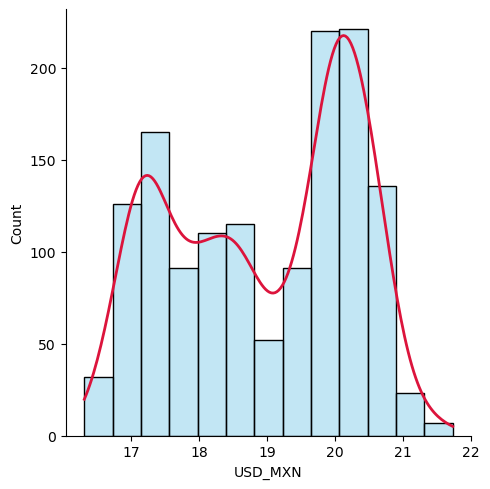

In [6]:
# para ver las distribuciones de las variables
#empezamos por  el USD_MXN
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.displot(
    data= df_main_clean,
    x= 'USD_MXN',
    kind='hist',
    kde=True,
    color='skyblue',
)
g.ax.lines[0].set_color('crimson')
g.ax.lines[0].set_linewidth(2)

plt.show()

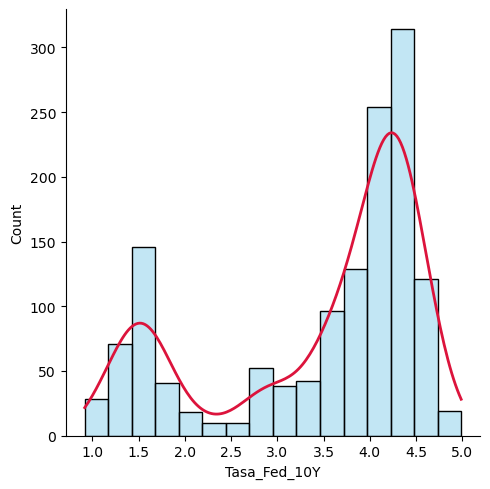

In [7]:
#para la Tasa_Fed_10Y

tasa_10Y = sns.displot(
    data= df_main_clean,
    x= 'Tasa_Fed_10Y',
    kind='hist',
    kde=True,
    color='skyblue'
)
tasa_10Y.ax.lines[0].set_color('crimson')
tasa_10Y.ax.lines[0].set_linewidth(2)

plt.show()

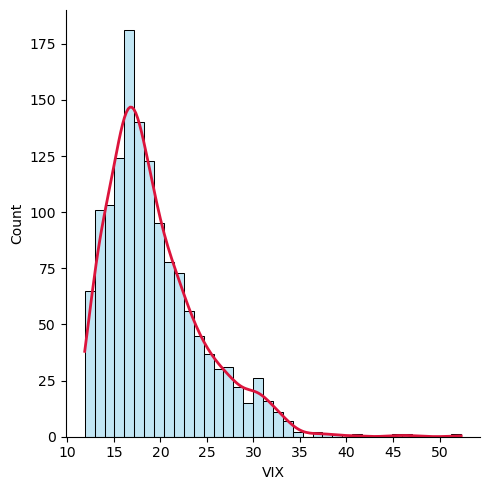

In [8]:
#para el VIX

g = sns.displot(
    data= df_main_clean,
    x= 'VIX',
    kind='hist',
    kde=True,
    color='skyblue'
)
g.ax.lines[0].set_color('crimson')
g.ax.lines[0].set_linewidth(2)

plt.show()

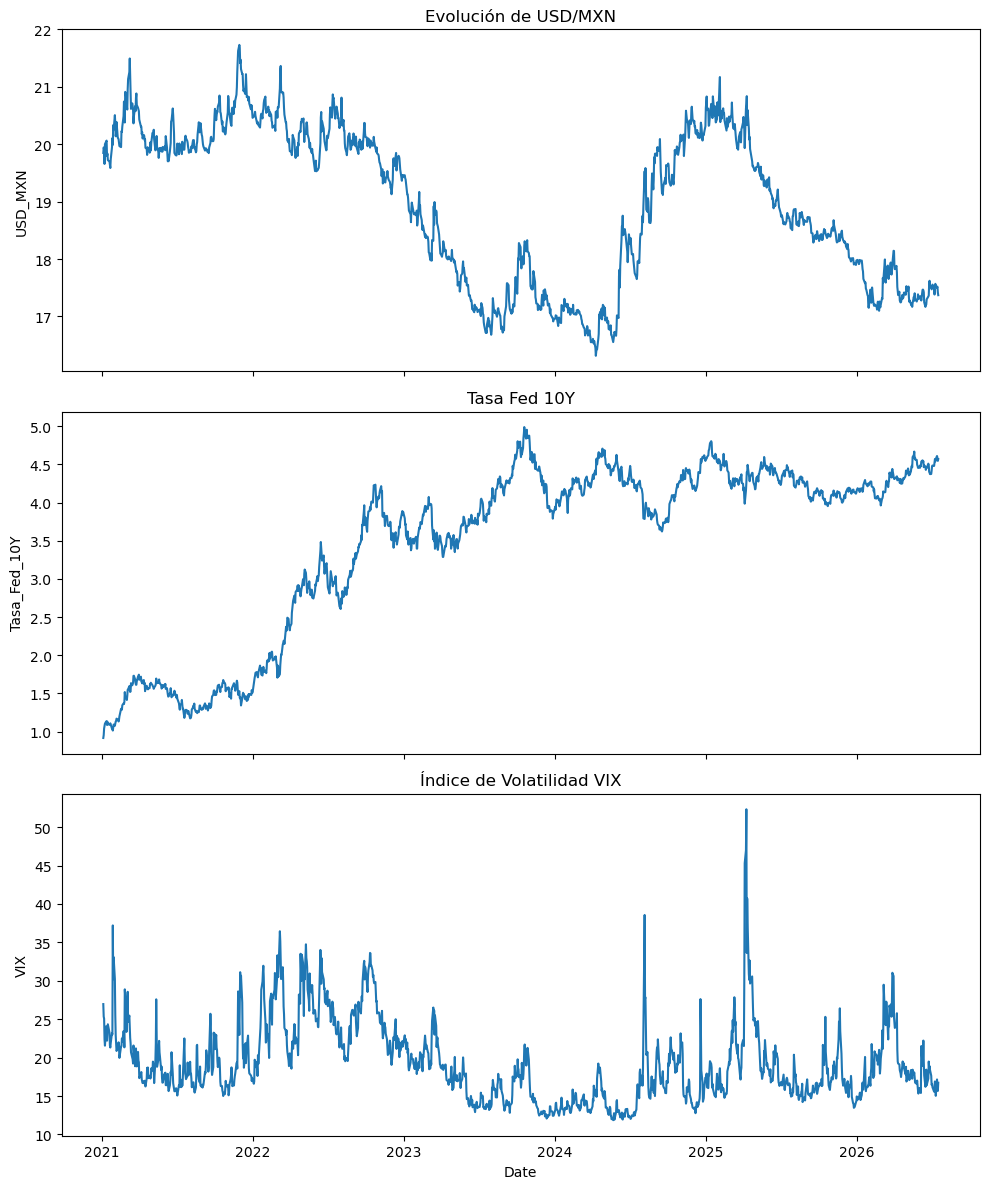

In [9]:

# 1. Creamos la estructura de 3 filas y 1 columna compartiendo el eje X
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 2. Graficamos cada variable asignando el parámetro 'ax'
sns.lineplot(data=df_main_clean, x=df_main_clean.index, y='USD_MXN', ax=axes[0])
axes[0].set_title('Evolución de USD/MXN')

sns.lineplot(data=df_main_clean, x=df_main_clean.index, y='Tasa_Fed_10Y', ax=axes[1])
axes[1].set_title('Tasa Fed 10Y')

sns.lineplot(data=df_main_clean, x=df_main_clean.index, y='VIX', ax=axes[2])
axes[2].set_title('Índice de Volatilidad VIX')

# Ajustamos el diseño para que no se encimen los textos
plt.tight_layout()
plt.show()


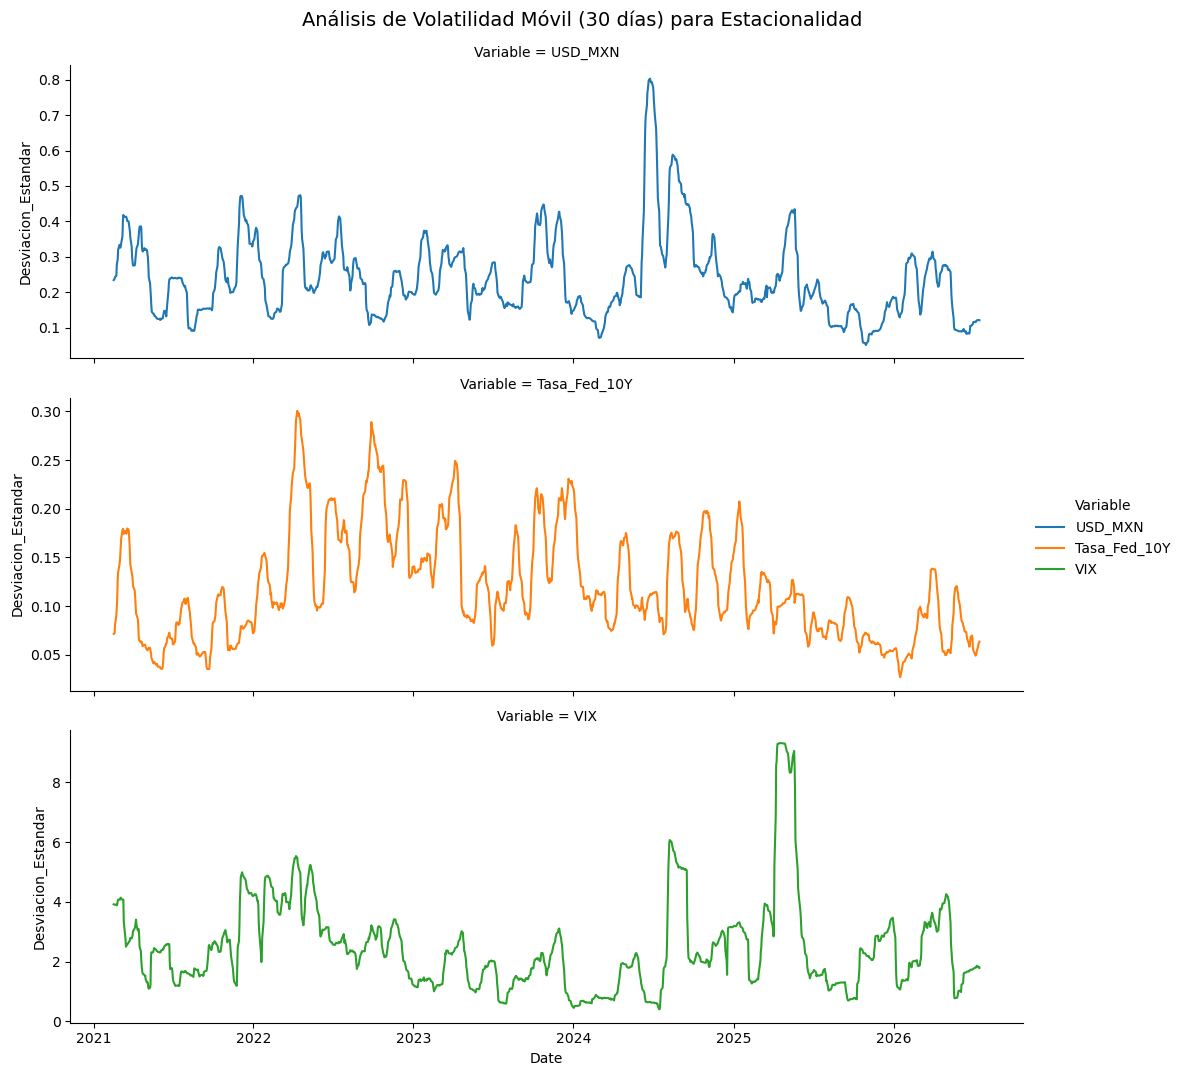

In [34]:
# 1. Calculamos la desviación estándar móvil para las 3 columnas al mismo tiempo
# Usamos .melt() para pasar el resultado a "formato largo" (long-form), ideal para Seaborn
df_volatilidad = (
    df_main_clean[['USD_MXN', 'Tasa_Fed_10Y', 'VIX']]
    .rolling(window=30)
    .std()
    .reset_index()
    .melt(id_vars=df_main_clean.index.name or 'index', var_name='Variable', value_name='Desviacion_Estandar')
)

# 2. Un solo relplot hace toda la magia
# El truco está en usar 'row' para apilar los gráficos verticalmente compartiendo el eje X
g = sns.relplot(
    data=df_volatilidad,
    x=df_main_clean.index.name or 'index',
    y='Desviacion_Estandar',
    row='Variable',      # Crea una fila por cada variable independiente
    hue='Variable',      # Les asigna un color diferente para distinguirlas mejor
    kind='line',
    height=3.5,          # Altura de cada panel individual
    aspect=3,            # Proporción ancho/alto de cada panel
    facet_kws=dict(sharey=False) # ¡Clave! Mismo eje X, pero cada variable mantiene su propia escala en Y
)

# 3. Personalización final del título general usando el objeto FacetGrid (g)
g.fig.suptitle('Análisis de Volatilidad Móvil (30 días) para Estacionalidad', y=1.02, fontsize=14)

plt.show()


In [35]:
from statsmodels.stats.diagnostic import het_arch

# 1. Definimos la lista de variables que queremos evaluar
variables = ['USD_MXN', 'Tasa_Fed_10Y', 'VIX']

print("=== REPORTE DE DIAGNÓSTICO DE VARIANZA (TEST ARCH) ===\n")

# 2. Iteramos sobre cada variable para aplicar el test de forma automática
for var in variables:
    # Ejecutamos el test ARCH sobre la columna correspondiente
    resultados_test = het_arch(df_main_clean[var])
    p_valor_varianza = resultados_test[1]
    
    print(f"Variable: {var}")
    print(f"  -> p-valor del Test de Varianza (Engle): {p_valor_varianza:.4f}")
    
    # Aplicamos el criterio de decisión senior
    if p_valor_varianza < 0.05:
        print(
            "  -> VERDICTO: ¡Alerta de Varianza Explosiva! Tu ruido cambia con el tiempo. "
            "REQUIERES APLICAR LOGARITMOS ANTES DE LOS TEST.\n"
        )
    else:
        print(
            "  -> VERDICTO: Varianza Constante (Homocedasticidad). "
            "Luz verde, puedes saltar directo a los test ADF y KPSS.\n"
        )


=== REPORTE DE DIAGNÓSTICO DE VARIANZA (TEST ARCH) ===

Variable: USD_MXN
  -> p-valor del Test de Varianza (Engle): 0.0000
  -> VERDICTO: ¡Alerta de Varianza Explosiva! Tu ruido cambia con el tiempo. REQUIERES APLICAR LOGARITMOS ANTES DE LOS TEST.

Variable: Tasa_Fed_10Y
  -> p-valor del Test de Varianza (Engle): 0.0000
  -> VERDICTO: ¡Alerta de Varianza Explosiva! Tu ruido cambia con el tiempo. REQUIERES APLICAR LOGARITMOS ANTES DE LOS TEST.

Variable: VIX
  -> p-valor del Test de Varianza (Engle): 0.0000
  -> VERDICTO: ¡Alerta de Varianza Explosiva! Tu ruido cambia con el tiempo. REQUIERES APLICAR LOGARITMOS ANTES DE LOS TEST.



In [36]:
# para aplicarle una transformación logarítmica a la par de que estabilizamos la media derivado de la naturaleza de la serie:

In [39]:
df_operability = np.log(df_main_clean).diff().dropna()

In [40]:
df_operability.head()

,USD_MXN,Tasa_Fed_10Y,VIX
Date,,,
2021-01-05,0.004773,0.040604,-0.062341
2021-01-06,-0.002020,0.087186,-0.010712
2021-01-07,-0.012459,0.027451,-0.113951
2021-01-08,0.017366,0.031253,-0.036881
2021-01-11,0.002516,0.024141,0.110542


In [41]:
df_operability.shape

(1388, 3)

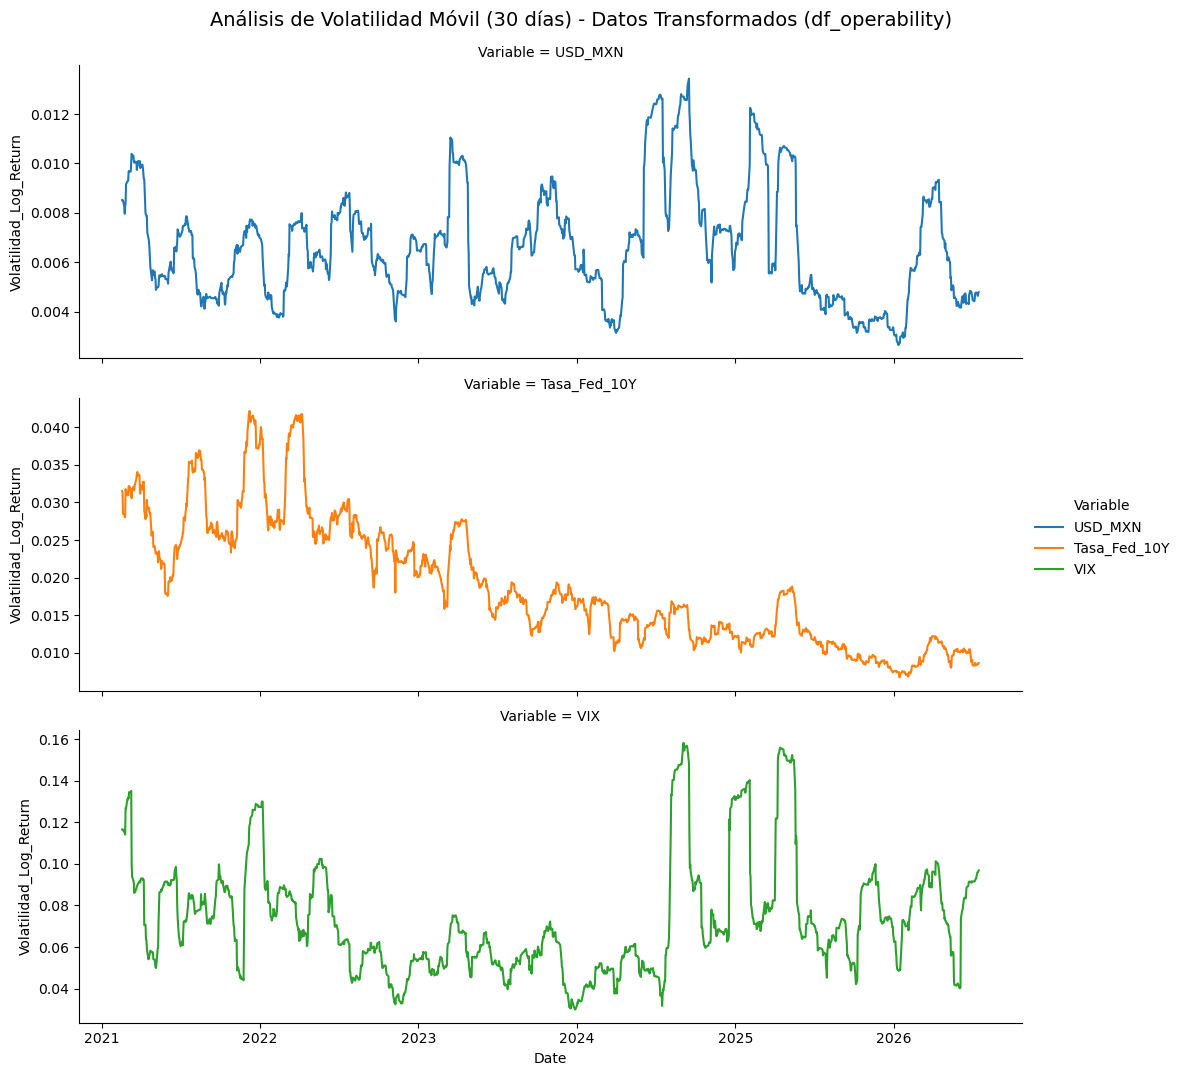

In [46]:
# 1. Calculamos la desviación estándar móvil (ventana de 30 días) para tus nuevas variables
# Usamos .melt() para transformarlo a formato largo (long-form) para Seaborn
df_vol_operability = (
    df_operability[['USD_MXN', 'Tasa_Fed_10Y', 'VIX']]
    .rolling(window=30)
    .std()
    .reset_index()
    .melt(
        id_vars=df_operability.index.name or 'index', 
        var_name='Variable', 
        value_name='Volatilidad_Log_Return'
    )
)

# 2. Creamos los páneles alineados con relplot
g = sns.relplot(
    data=df_vol_operability,
    x=df_operability.index.name or 'index',
    y='Volatilidad_Log_Return',
    row='Variable',      # Una fila independiente para cada indicador
    hue='Variable',      # Color personalizado por variable
    kind='line',
    height=3.5,          # Altura de cada panel
    aspect=3,            # Proporción ancho/alto
    facet_kws=dict(sharey=False) # Cada indicador mantiene su propia escala de volatilidad
)

# 3. Personalización del título de la figura
g.fig.suptitle(
    'Análisis de Volatilidad Móvil (30 días) - Datos Transformados (df_operability)', 
    y=1.02, 
    fontsize=14
)

plt.show()


In [45]:

# 1. Definimos la lista de variables que queremos evaluar
variables = ['USD_MXN', 'Tasa_Fed_10Y', 'VIX']

print("=== REPORTE DE DIAGNÓSTICO DE VARIANZA (TEST ARCH) ===\n")

# 2. Iteramos sobre cada variable para aplicar el test de forma automática
for var in variables:
    # Ejecutamos el test ARCH sobre la columna correspondiente
    resultados_test = het_arch(df_operability[var])
    p_valor_varianza = resultados_test[1]
    
    print(f"Variable: {var}")
    print(f"  -> p-valor del Test de Varianza (Engle): {p_valor_varianza:.4f}")
    
    # Aplicamos el criterio de decisión senior
    if p_valor_varianza < 0.05:
        print(
            "  -> VERDICTO: ¡Alerta de Varianza Explosiva! Tu ruido cambia con el tiempo. "
            "REQUIERES APLICAR LOGARITMOS ANTES DE LOS TEST.\n"
        )
    else:
        print(
            "  -> VERDICTO: Varianza Constante (Homocedasticidad). "
            "Luz verde, puedes saltar directo a los test ADF y KPSS.\n"
        )


=== REPORTE DE DIAGNÓSTICO DE VARIANZA (TEST ARCH) ===

Variable: USD_MXN
  -> p-valor del Test de Varianza (Engle): 0.0000
  -> VERDICTO: ¡Alerta de Varianza Explosiva! Tu ruido cambia con el tiempo. REQUIERES APLICAR LOGARITMOS ANTES DE LOS TEST.

Variable: Tasa_Fed_10Y
  -> p-valor del Test de Varianza (Engle): 0.0000
  -> VERDICTO: ¡Alerta de Varianza Explosiva! Tu ruido cambia con el tiempo. REQUIERES APLICAR LOGARITMOS ANTES DE LOS TEST.

Variable: VIX
  -> p-valor del Test de Varianza (Engle): 0.0000
  -> VERDICTO: ¡Alerta de Varianza Explosiva! Tu ruido cambia con el tiempo. REQUIERES APLICAR LOGARITMOS ANTES DE LOS TEST.



In [47]:
from statsmodels.stats.diagnostic import het_arch

# 1. Definimos las variables a evaluar en el nuevo DataFrame
variables = ['USD_MXN', 'Tasa_Fed_10Y', 'VIX']

print("=== REPORTE DE CONFIRMACIÓN DE VARIANZA (TEST ARCH) - df_operability ===\n")

# 2. Iteramos de forma automática sobre cada columna
for var in variables:
    # Ejecutamos el test ARCH
    resultados_test = het_arch(df_operability[var])
    p_valor_varianza = resultados_test[1]
    
    print(f"Variable: {var}")
    print(f"  -> Nuevo p-valor del Test de Varianza (Engle): {p_valor_varianza:.4f}")
    
    # Aplicamos el criterio de decisión post-transformación
    if p_valor_varianza < 0.05:
        print(
            "  -> VERDICTO: ¡Persiste la Varianza Explosiva! La transformación logarítmica "
            "no fue suficiente. Podrías requerir una ventana de diferenciación más amplia o modelos GARCH.\n"
        )
    else:
        print(
            "  -> VERDICTO: Varianza Constante (Homocedasticidad) Lograda. "
            "¡Luz verde! Has domado la volatilidad. Puedes proceder con total seguridad.\n"
        )


=== REPORTE DE CONFIRMACIÓN DE VARIANZA (TEST ARCH) - df_operability ===

Variable: USD_MXN
  -> Nuevo p-valor del Test de Varianza (Engle): 0.0000
  -> VERDICTO: ¡Persiste la Varianza Explosiva! La transformación logarítmica no fue suficiente. Podrías requerir una ventana de diferenciación más amplia o modelos GARCH.

Variable: Tasa_Fed_10Y
  -> Nuevo p-valor del Test de Varianza (Engle): 0.0000
  -> VERDICTO: ¡Persiste la Varianza Explosiva! La transformación logarítmica no fue suficiente. Podrías requerir una ventana de diferenciación más amplia o modelos GARCH.

Variable: VIX
  -> Nuevo p-valor del Test de Varianza (Engle): 0.0000
  -> VERDICTO: ¡Persiste la Varianza Explosiva! La transformación logarítmica no fue suficiente. Podrías requerir una ventana de diferenciación más amplia o modelos GARCH.



In [49]:
df_operability.head()

,USD_MXN,Tasa_Fed_10Y,VIX
Date,,,
2021-01-05,0.004773,0.040604,-0.062341
2021-01-06,-0.002020,0.087186,-0.010712
2021-01-07,-0.012459,0.027451,-0.113951
2021-01-08,0.017366,0.031253,-0.036881
2021-01-11,0.002516,0.024141,0.110542


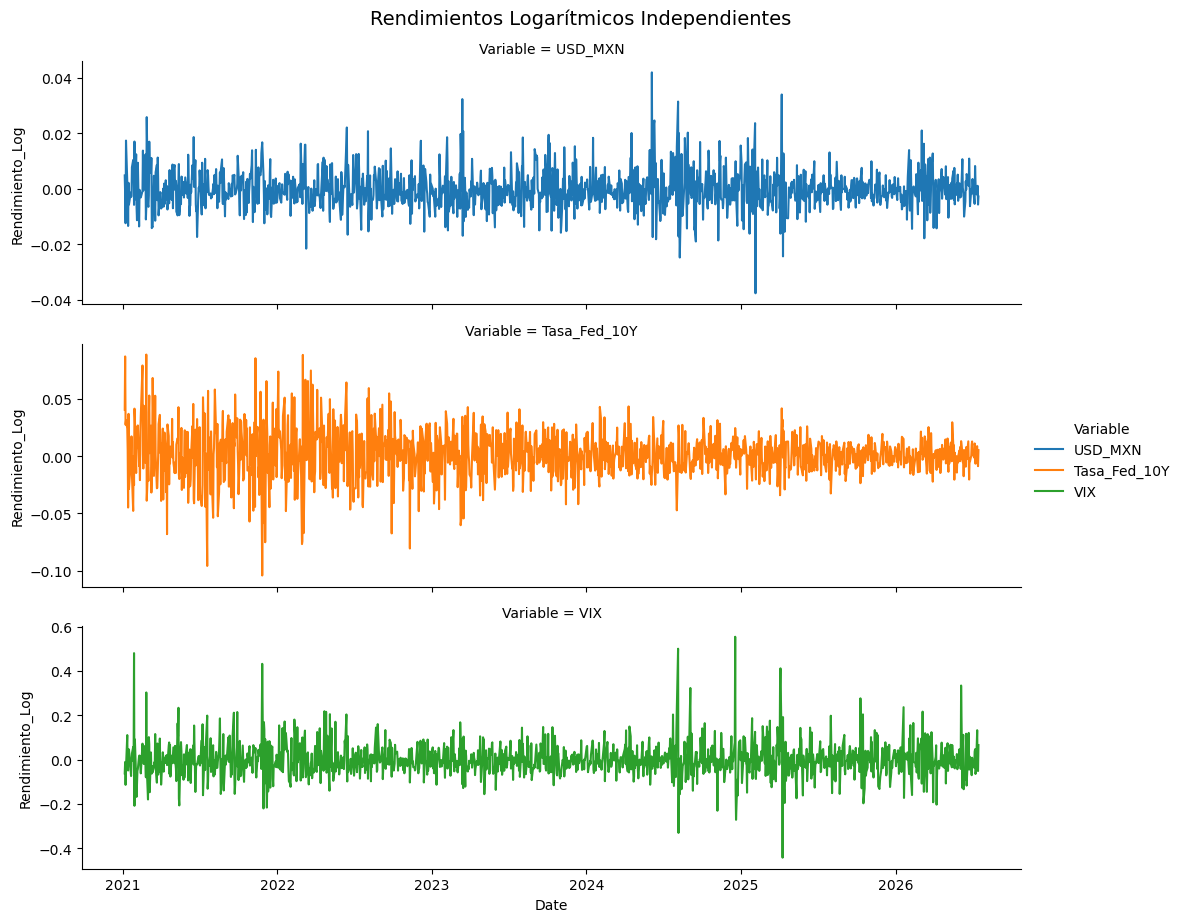

In [51]:
# 1. Pasamos df_operability a formato largo (long-form)
df_long_operability = (
    df_operability[['USD_MXN', 'Tasa_Fed_10Y', 'VIX']]
    .reset_index()
    .melt(
        id_vars=df_operability.index.name or 'index', 
        var_name='Variable', 
        value_name='Rendimiento_Log'
    )
)

# 2. Graficamos rompiendo la escala compartida de Y
g = sns.relplot(
    data=df_long_operability,
    x=df_operability.index.name or 'index',
    y='Rendimiento_Log',
    row='Variable',      # Cada variable va en su propia fila
    hue='Variable',      # Color diferente para cada una
    kind='line',
    height=3,
    aspect=3.5,
    facet_kws=dict(sharey=False) # ¡ESTO EVITA EL APLASTAMIENTO! Cada gráfica usa su propia escala en Y
)

g.fig.suptitle('Rendimientos Logarítmicos Independientes', y=1.02, fontsize=14)
plt.show()
